# Tutorial: Operator learning
### Fourier neural operator
Example PDE: 1D Burgers equation

---

Lecture: "Physics-augmented machine learning" @ Cyber-Physical Simulation, TU Darmstadt

Lecturer: Prof. Oliver Weeger

Author: Fabian J. Roth

Inspiration and parts of this notebook are taken from [Ceyron's GitHub](https://github.com/Ceyron/FNO-in-JAX/blob/main/README.md), who also provides a detailed [YouTube Video](https://www.youtube.com/watch?v=74uwQsBTIVo) about a FNO implementation.

---

#### In this notebook, you will...

* <span style="color:red">learn something</span>

# 0. Installation
Run the following code cell to install the required packages. Then **restart your session** to make these packages available.

In [1]:
def is_colab():
    """Determine if the code is running in Google Colab."""
    try:
        import google.colab

        return True
    except ImportError:
        return False


if is_colab():
    print("Running in Google Colab, trying to install LecturePhysicsAwareML...")
    !git clone --depth 1 https://github.com/CPShub/LecturePhysicsAwareML.git

    # Get the data Mathworks (the creators of Matlab) host the original Li et al. dataset in the .mat format
    !wget https://ssd.mathworks.com/supportfiles/nnet/data/burgers1d/burgers_data_R10.mat

    # Install the package
    %cd LecturePhysicsAwareML/operator_learning
    %pip install -e .
    print(
        "\n************************************************************************************\nMake sure to restart the session after installation (Runtime > Restart Session).\n********************************************************************************"
    )
else:
    print(
        "Not running in Google Colab. \nPlease add the data and install the package manually if needed. The data can be downloaded here: https://ssd.mathworks.com/supportfiles/nnet/data/burgers1d/burgers_data_R10.mat. \nIf you are using pip, run:\n>>> pip install -e .\nin the operator_learning directory."
    )


Not running in Google Colab. 
Please add the data and install the package manually if needed. The data can be downloaded here: https://ssd.mathworks.com/supportfiles/nnet/data/burgers1d/burgers_data_R10.mat. 
If you are using pip, run:
>>> pip install -e .
in the operator_learning directory.


## Import required packages

In [54]:
import jax
import jax.numpy as jnp
import jax.random as jr

from operator_learning import FNO
from klax import split_data, fit

import optax

from scipy.io import loadmat

from matplotlib import pyplot as plt
from ipywidgets import interact, BoundedIntText, Dropdown

jax.config.update("jax_enable_x64", True)

In this notebook, we will mimic one example done in the original paper by [Li et al.](https://arxiv.org/pdf/2010.08895.pdf) as implemented in their [reference code](https://github.com/neuraloperator/neuraloperator/blob/af93f781d5e013f8ba5c52baa547f2ada304ffb0/fourier_1d.py) to solve the [**1D Burgers equation**](https://en.wikipedia.org/wiki/Burgers%27_equation)

$$
\begin{align}
    \frac{\partial u}{\partial t} + \frac{1}{2}\frac{\partial u^2}{\partial x} = \nu \frac{\partial^2 u}{\partial x^2}, & \qquad x\in(0,1),\,t\in(0,1]\\
    u(0, x) = u_0(x), & \qquad x\in(0,1)
\end{align}
$$
$$  $$

The domain $\Omega = (0, 1)$ is periodic, i.e., $u(t, x=0) = u(t, x=1)$. The diffusivity is fixed to $\nu=0.1$. Our dataset consists of $2048$ initial conditions $u(t=0, x)$ and the corresponding solution at time one $u(t=1, x)$. The functions are sampled at $N=8192$ equidistant points $x_i$. 

Our goal is to fit an FNO to learn the mapping from initial condition $u(t=0, x)$ to state at time one $u(t=1, x)$. 

Let's have a look at the data.

In [115]:
# Load the data
try:
    data = loadmat(R"/content/burgers_data_r10.mat")
except FileNotFoundError:
    data = loadmat(R"../data/burgers_data_r10.mat")

u0s     = data["a"]         # u(t=0, x)
u0_xs   = data["a_x"]       # du_dx(t=0, x)
u0_xs   = jnp.append(u0_xs, u0_xs[:, :1], axis=1)
u1s     = data["u"]         # u(t=1, x)
xs      = jnp.linspace(0, 1, u0s.shape[1])

In [87]:
@interact(sample_index=BoundedIntText(
    min=0, max=u0s.shape[0]-1, step=1, value=0, description="Sample Index"))
def update_plot(sample_index):
    fig, ax = plt.subplots(figsize=(7,3.5), dpi=150)
    ax.plot(xs, u0s[sample_index], label="Initial condition $u(t=0, x)$")
    ax.plot(xs, u1s[sample_index], label="$u(t=1, x)$")
    ax.set(
        xlabel = "$x$",
        ylabel = "$u$",
        title = f"Data sample {sample_index}",
        xlim = [0,1]
    )
    ax.legend(loc=4)
    plt.tight_layout()

interactive(children=(BoundedIntText(value=0, description='Sample Index', max=2047), Output()), _dom_classes=(…

In [130]:
xs_batched = jnp.repeat(xs[None, :], u0s.shape[0], axis=0)
in_data = u0s[:, :, None]                           # Add channel dimension

print("Pick your training data parameters")
@interact(in_data_option=Dropdown(options=["Only u0", "u0 and x"], value="Only u0", description="Input data:"), se=Dropdown(options=[5, 6, 7, 8, 9], value=9, description="Coarsen level:"))
def make_input_data(in_data_option, se):
    global dataset_coarse, x_coarse
    if in_data_option == "Only u0":
        in_data = u0s[:, :, None]                           # Add channel dimension
    elif in_data_option == "u0 and x":
        in_data = jnp.stack([u0s, xs_batched], axis=-1)     # Add x channel
    else:
        raise ValueError("Unkown in_data_option")

    stride = 2**se
    dataset_coarse = (in_data[:, ::stride], u1s[:, ::stride])
    x_coarse = xs[::stride]

    fig, ax = plt.subplots(figsize=(7,3.5), dpi=150)
    for data, label, c in zip(dataset_coarse[0][0].T, ["$u(x,t=0)$", "x"], ['black', 'blue']):
        ax.plot(x_coarse, data, marker="o", c=c, label=label)
    ax.plot(x_coarse, dataset_coarse[1][0], marker="s", c='orange', label="Solution $u(x,t=1)$")
    ax.legend()
    plt.tight_layout()
    plt.show()

dataset_fine = (in_data, u1s)

Pick your training data parameters


interactive(children=(Dropdown(description='Input data:', options=('Only u0', 'u0 and x'), value='Only u0'), D…

Step: 10000, Loss: 1.989e-04, Validation loss: 2.009e-04
Step: 10000, Loss: 1.243e-04, Validation loss: 1.210e-04
Step: 10000, Loss: 1.904e-04, Validation loss: 1.827e-04

Step: 0, Loss: 7.637e-01, Validation loss: 7.658e-01
Step: 100, Loss: 7.636e-02, Validation loss: 7.584e-02
Step: 200, Loss: 4.354e-02, Validation loss: 4.420e-02
Step: 300, Loss: 2.816e-02, Validation loss: 2.838e-02
Step: 400, Loss: 2.258e-02, Validation loss: 2.219e-02
Step: 500, Loss: 2.041e-02, Validation loss: 1.988e-02
Step: 600, Loss: 1.859e-02, Validation loss: 1.801e-02
Step: 700, Loss: 1.702e-02, Validation loss: 1.649e-02
Step: 800, Loss: 1.520e-02, Validation loss: 1.487e-02
Step: 900, Loss: 1.315e-02, Validation loss: 1.298e-02
Step: 1000, Loss: 1.123e-02, Validation loss: 1.133e-02
Step: 1100, Loss: 9.732e-03, Validation loss: 1.002e-02
Step: 1200, Loss: 8.765e-03, Validation loss: 9.174e-03
Step: 1300, Loss: 8.177e-03, Validation loss: 8.635e-03
Step: 1400, Loss: 7.574e-03, Validation loss: 8.015e-03
Step: 1500, Loss: 7.140e-03, Validation loss: 7.566e-03
Step: 1600, Loss: 6.753e-03, Validation loss: 7.162e-03
Step: 1700, Loss: 6.398e-03, Validation loss: 6.791e-03
Step

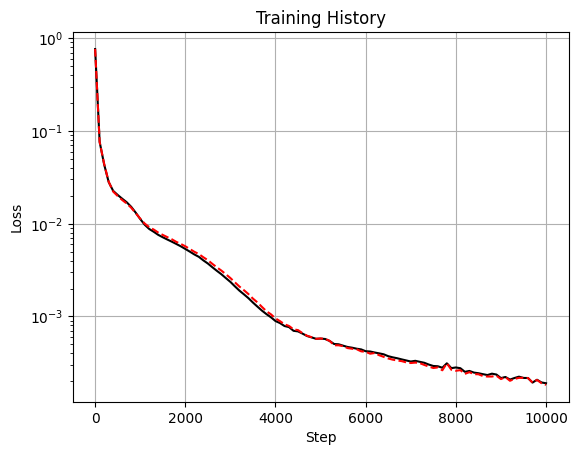

In [118]:
key = jr.key(1)
key_split, model_key, training_key = jr.split(key, 3)

train_data_coarse, test_data_coarse = split_data(
    dataset_coarse, (0.9, 0.1), batch_axis=0, key=key_split
)
train_data_fine, test_data_fine = split_data(
    dataset_fine, (0.9, 0.1), batch_axis=0, key=key_split
)

in_channels = train_data_coarse[0].shape[-1]
fno = FNO(in_channels, "scalar", num_modes=9, hidden_channels=10, depth=2, key=model_key)

fno, history = fit(
    fno,
    train_data_coarse,
    batch_size=64,
    validation_data=test_data_coarse,
    steps=10_000,
    optimizer=optax.adam(1e-4),
    key=training_key,
)

history.plot()  # type: ignore

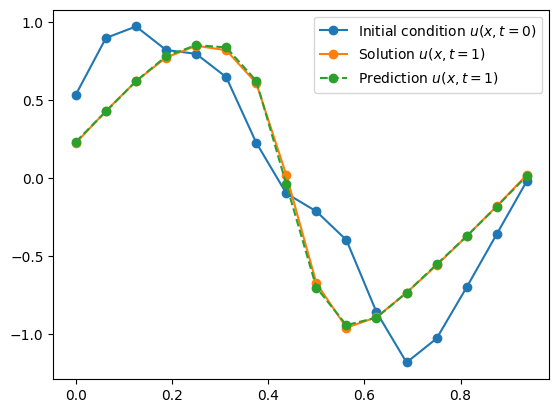

In [120]:
## Evaluation
u0_test, u1_test = test_data_coarse

u1_test_pred = jax.vmap(fno)(u0_test)

n = 1

plt.plot(x_coarse, u0_test[n, :, 0],   marker="o", label="Initial condition $u(x,t=0)$")
plt.plot(x_coarse, u1_test[n],      marker="o", label="Solution $u(x,t=1)$")
plt.plot(x_coarse, u1_test_pred[n], marker="o", ls="--", label="Prediction $u(x,t=1)$")
plt.legend()
plt.show()


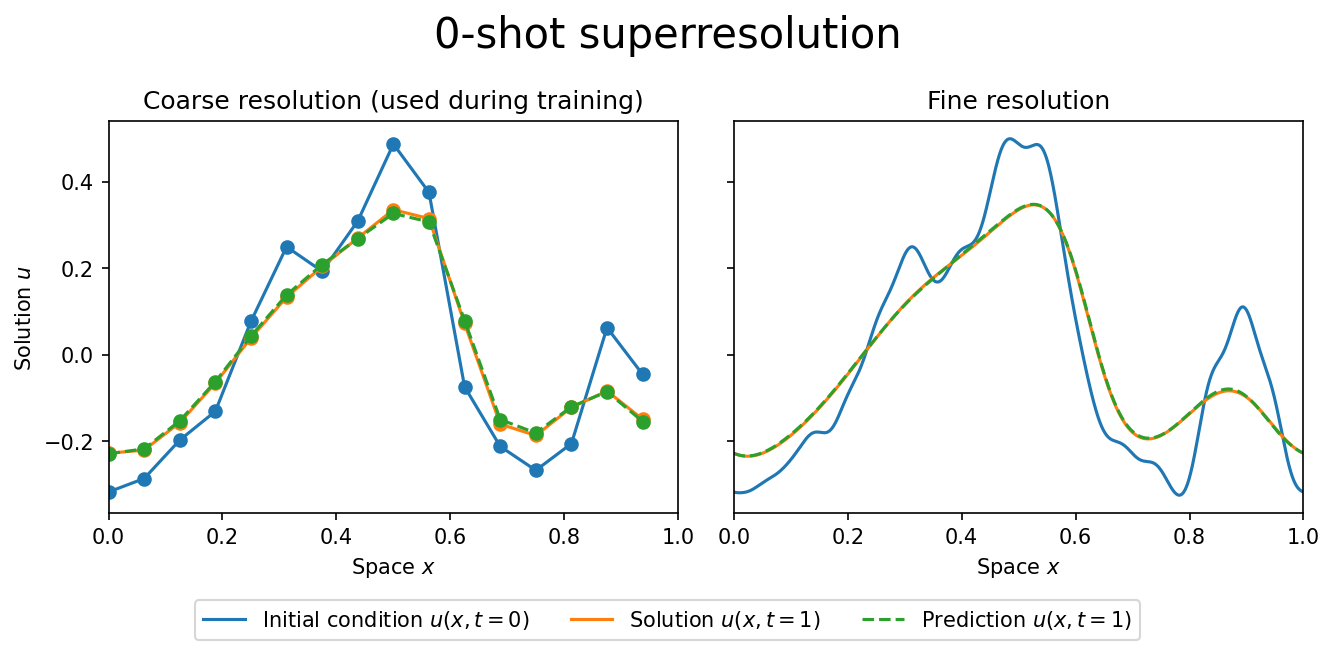

In [128]:
## Try 0-shot superresolution
n = 2   # Index of the test case in the test dataset

u0_test_coarse, u1_test_coarse = test_data_coarse
u0_test_fine, u1_test_fine = test_data_fine

u1_test_coarse_pred = fno(u0_test_coarse[n])
u1_test_fine_pred = fno(u0_test_fine[n])

fig, axes = plt.subplots(1, 2, figsize=(9,4), dpi=150, sharey=True)

axes[0].plot(x_coarse, u0_test_coarse[n],   marker="o", label="Initial condition $u(x,t=0)$")
axes[0].plot(x_coarse, u1_test_coarse[n],   marker="o", label="Solution $u(x,t=1)$")
axes[0].plot(x_coarse, u1_test_coarse_pred, marker="o", ls="--", label="Prediction $u(x,t=1)$")
axes[0].set(
    xlabel = "Space $x$",
    xlim = [0, 1],
    ylabel = "Solution $u$",
    title  = "Coarse resolution (used during training)",
)

axes[1].plot(x, u0_test_fine[n], label="Initial condition $u(x,t=0)$")
axes[1].plot(x, u1_test_fine[n], label="Solution $u(x,t=1)$")
axes[1].plot(x, u1_test_fine_pred, ls="--", label="Prediction $u(x,t=1)$")
axes[1].set(
    xlabel = "Space $x$",
    xlim = [0, 1],
    title  = "Fine resolution",
)
# Combine handles and labels from both axes
handles, labels = axes[1].get_legend_handles_labels()

# Place the legend below both plots, centered, in one line
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=len(labels), frameon=True)
fig.suptitle("0-shot superresolution", fontsize=20)
plt.tight_layout()
plt.show()

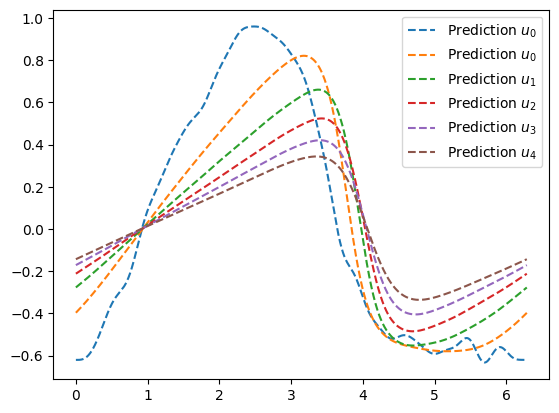

In [199]:
## Trying out autoregressive unrolling
u0_test_fine, u1_test_fine = test_data_fine

pred = u0_test_fine[0]
plt.plot(x, pred, ls="--", label="Prediction $u_0$")
for i in range(5):
    pred = fno(pred)
    plt.plot(x, pred, ls="--", label=f"Prediction $u_{i}$")

plt.legend()
plt.show()